<a href="https://colab.research.google.com/github/9terry-student/PyTorch/blob/main/16_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 16장 이미지 인식의 꽃, 컨볼루션 신경망(CNN)

## 1. 이미지를 인식하는 원리

In [2]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt
import sys

# MNIST 데이터셋 호출 및 학습셋과 테스트셋으로 저장
(X_train,y_train),(X_test,y_test)=mnist.load_data()

# 학습셋과 테스트셋의 이미지 개수 확인
print('학습셋 이미지 수: %d개'%(X_train.shape[0]))
print('테스트셋 이미지 수: %d개'%(X_test.shape[0]))

학습셋 이미지 수: 60000개
테스트셋 이미지 수: 10000개


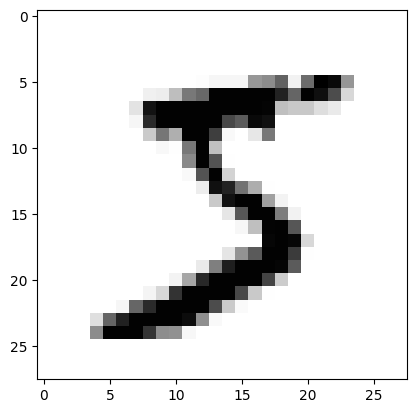

In [3]:
# 첫번째 이미지 확인
plt.imshow(X_train[0],cmap='Greys')
plt.show()

In [4]:
# 이미지 인식 원리
for x in X_train[0]:
  for i in x:
    sys.stdout.write('%-3s'%i)
  sys.stdout.write('\n')

0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  3  18 18 18 12613617526 1662552471270  0  0  0  
0  0  0  0  0  0  0  0  30 36 94 15417025325325325325322517225324219564 0  0  0  0  
0  0  0  0  0  0  0  49 23825325325325325325325325325193 82 82 56 39 0  0  0  0  0  
0  0  0  0  0  0  0  18 2192532532532532531981822472410  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  80 15610725325320511 0  43 1540  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  14 1  15425390 0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  1392531902  0  0  0  0  0  0  0 

In [5]:
# 차원 변환 과정 실습
X_train=X_train.reshape(X_train.shape[0],784)
X_train=X_train.astype('float64')
X_train/=255

X_test=X_test.reshape(X_test.shape[0],784).astype('float64')/255

# 클래스 값 확인
print('class: %d'%(y_train[0]))

# 바이너리화 과정 실습
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

print(y_train[0])

class: 5
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## 2. 딥러닝 기본 프레임 만들기

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt
import numpy as np
import os

# MNIST 데이터 호출
(X_train,y_train),(X_test,y_test)=mnist.load_data()

# 차원 변환, 테스트셋과 학습셋으로 나눔
X_train=X_train.reshape(X_train.shape[0],784).astype('float32')/255
X_test=X_test.reshape(X_test.shape[0],784).astype('float32')/255

y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

# 모델 구조 설정
model=Sequential()
model.add(Dense(512,input_dim=784,activation='relu'))
model.add(Dense(10,activation='softmax'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# 모델 실행 환경 설정
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

# 모델 최적화 설정
modelpath='./MNIST_MLP.keras'
checkpointer=ModelCheckpoint(filepath=modelpath,monitor='val_loss',verbose=1,save_best_only=True)
early_stopping_callback=EarlyStopping(monitor='val_loss',patience=10)

# 모델 실행
history=model.fit(X_train,y_train,validation_split=0.25,epochs=30,batch_size=200,verbose=0,
                  callbacks=[early_stopping_callback,checkpointer])

# 테스트 정확도 출력
print('\n Test Accuracy: %.4f'%(model.evaluate(X_test,y_test)[1]))


Epoch 1: val_loss improved from None to 0.19271, saving model to ./MNIST_MLP.keras

Epoch 1: finished saving model to ./MNIST_MLP.keras

Epoch 2: val_loss improved from 0.19271 to 0.14132, saving model to ./MNIST_MLP.keras

Epoch 2: finished saving model to ./MNIST_MLP.keras

Epoch 3: val_loss improved from 0.14132 to 0.11303, saving model to ./MNIST_MLP.keras

Epoch 3: finished saving model to ./MNIST_MLP.keras

Epoch 4: val_loss improved from 0.11303 to 0.10112, saving model to ./MNIST_MLP.keras

Epoch 4: finished saving model to ./MNIST_MLP.keras

Epoch 5: val_loss improved from 0.10112 to 0.09078, saving model to ./MNIST_MLP.keras

Epoch 5: finished saving model to ./MNIST_MLP.keras

Epoch 6: val_loss did not improve from 0.09078

Epoch 7: val_loss improved from 0.09078 to 0.08882, saving model to ./MNIST_MLP.keras

Epoch 7: finished saving model to ./MNIST_MLP.keras

Epoch 8: val_loss improved from 0.08882 to 0.08290, saving model to ./MNIST_MLP.keras

Epoch 8: finished saving mo

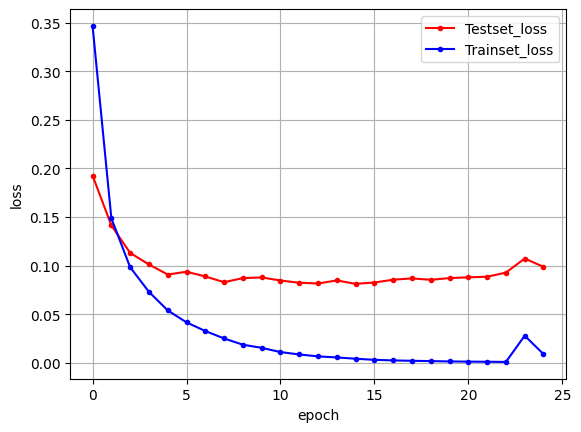

In [8]:
# 검증셋과 학습셋의 오차 저장
y_vloss=history.history['val_loss']
y_loss=history.history['loss']

# 그래프로 표현
x_len=np.arange(len(y_loss))
plt.plot(x_len,y_vloss,marker='.',c='red',label='Testset_loss')
plt.plot(x_len,y_loss,marker='.',c='blue',label='Trainset_loss')

# 그래프에 그리드 및 레이블 표시
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

## 5. 컨볼루션 신경망 실행하기

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt
import numpy as np

# 데이터 호출
(X_train,y_train),(X_test,y_test)=mnist.load_data()
X_train=X_train.reshape(X_train.shape[0],28,28,1).astype('float32')/255
X_test=X_test.reshape(X_test.shape[0],28,28,1).astype('float32')/255
y_train=to_categorical(y_train)
y_test=to_categorical(y_test)

# 컨볼루션 신경망 설정
model=Sequential()
model.add(Conv2D(32,kernel_size=(3,3),input_shape=(28,28,1),activation='relu'))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10,activation='softmax'))

# 모델 실행 옵션 설정
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# 모델 최적화 설정
modelpath='./MNIST_CNN.keras'
checkpointer=ModelCheckpoint(filepath=modelpath,monitor='val_loss',verbose=1,save_best_only=True)
early_stopping_callback=EarlyStopping(monitor='val_loss',patience=10)

# 모델 실행
history=model.fit(X_train,y_train,validation_split=0.25,epochs=30,batch_size=200,verbose=0,
                  callbacks=[early_stopping_callback,checkpointer])

# 테스트 정확도 출력
print('\n Test Accuracy: %.4f'%(model.evaluate(X_test,y_test)[1]))

Exception ignored in: <function _xla_gc_callback at 0x793d2eec3a60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jax/_src/lib/__init__.py", line 127, in _xla_gc_callback
    def _xla_gc_callback(*args):
    
KeyboardInterrupt: 


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch 1: val_loss improved from None to 0.07946, saving model to ./MNIST_CNN.keras

Epoch 1: finished saving model to ./MNIST_CNN.keras

Epoch 2: val_loss improved from 0.07946 to 0.05605, saving model to ./MNIST_CNN.keras

Epoch 2: finished saving model to ./MNIST_CNN.keras

Epoch 3: val_loss improved from 0.05605 to 0.04795, saving model to ./MNIST_CNN.keras

Epoch 3: finished saving model to ./MNIST_CNN.keras

Epoch 4: val_loss improved from 0.04795 to 0.04603, saving model to ./MNIST_CNN.keras

Epoch 4: finished saving model to ./MNIST_CNN.keras

Epoch 5: val_loss improved from 0.04603 to 0.04575, saving model to ./MNIST_CNN.keras

Epoch 5: finished saving model to ./MNIST_CNN.keras

Epoch 6: val_loss improved from 0.04575 to 0.04498, saving model to ./MNIST_CNN.keras

Epoch 6: finished saving model to ./MNIST_CNN.keras

Epoch 7: val_loss did not improve from 0.04498

Epoch 8: val_loss improved from 0.04498 to 0.04334, saving model to ./MNIST_CNN.keras

Epoch 8: finished saving mo

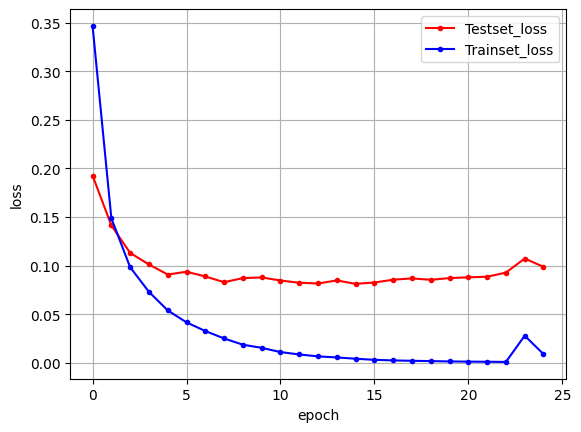

In [9]:
# 검증셋과 학습셋 오차 저장
y_vloss=history.history['val_loss']
y_loss=history.history['loss']

# 그래프 표현
x_len=np.arange(len(y_loss))
plt.plot(x_len,y_vloss,marker='.',c='red',label='Testset_loss')
plt.plot(x_len,y_loss,marker='.',c='blue',label='Trainset_loss')

# 그래프에 그리드 및 레이블 표시
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()